# GAN 예제: 1차원 정규분포 학습

이 노트북은 GAN의 핵심을 최대한 단순하게 이해하기 위한 PyTorch 예제입니다.

- 실제 데이터: $x \sim \mathcal{N}(4,1)$
- 노이즈: $z \sim \mathcal{N}(0,1)$
- Generator 목표: 실제 데이터 분포와 비슷한 값을 생성
- Discriminator 목표: 실제 데이터와 생성 데이터를 구분


## GAN 목적함수

$$
\min_G \max_D \left[
\mathbb{E}_{x\sim p_{data}}[\log D(x)]
+ \mathbb{E}_{z\sim p_z}[\log(1-D(G(z)))]
\right]
$$

- $D(x)$: 실제 샘플을 진짜라고 판단할 확률
- $G(z)$: 노이즈 $z$로부터 만든 가짜 샘플
- $D(G(z))$: 생성 샘플을 진짜라고 판단할 확률

D는 실제에는 1, 가짜에는 0을 출력하려 하고, G는 D가 가짜를 1이라고 판단하도록 학습됩니다.


In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


## 데이터 샘플러


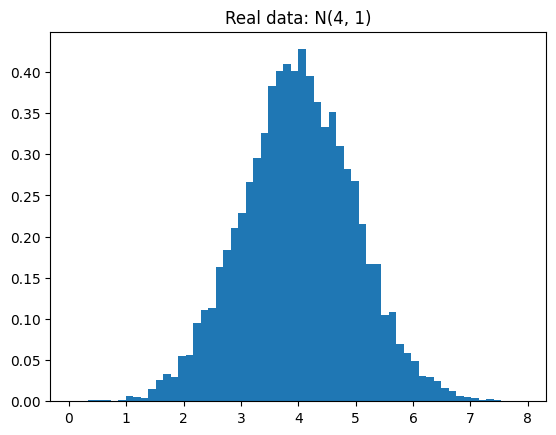

In [2]:
def sample_real(batch_size):
    # 실제 데이터: N(4, 1)
    return torch.randn(batch_size, 1, device=device) + 4.0

def sample_noise(batch_size, latent_dim=1):
    # Generator 입력 노이즈
    return torch.randn(batch_size, latent_dim, device=device)

real = sample_real(10000).cpu().numpy().ravel()
plt.hist(real, bins=60, density=True)
plt.title('Real data: N(4, 1)')
plt.show()


## Generator / Discriminator


In [3]:
class Generator(nn.Module):
    def __init__(self, latent_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x)

G = Generator().to(device)
D = Discriminator().to(device)

print(G)
print(D)


Generator(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=16, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


## Loss / Optimizer

`BCEWithLogitsLoss`는 sigmoid와 binary cross entropy를 안정적으로 결합한 함수입니다.


In [4]:
criterion = nn.BCEWithLogitsLoss()
g_optimizer = torch.optim.Adam(G.parameters(), lr=2e-3, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(D.parameters(), lr=2e-3, betas=(0.5, 0.999))


## 학습

D를 먼저 한 번 학습하고, 이어서 G를 한 번 학습합니다.

`fake.detach()`는 D를 학습할 때 G까지 gradient가 흘러가지 않게 합니다.


In [5]:
batch_size = 256
steps = 5000
d_losses = []
g_losses = []

for step in range(1, steps + 1):
    # 1) Discriminator 학습
    real = sample_real(batch_size)
    fake = G(sample_noise(batch_size))

    real_logits = D(real)
    fake_logits = D(fake.detach())

    d_real_loss = criterion(real_logits, torch.ones_like(real_logits))
    d_fake_loss = criterion(fake_logits, torch.zeros_like(fake_logits))
    d_loss = d_real_loss + d_fake_loss

    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()

    # 2) Generator 학습
    fake = G(sample_noise(batch_size))
    fake_logits = D(fake)

    # non-saturating loss: -log(D(G(z)))
    g_loss = criterion(fake_logits, torch.ones_like(fake_logits))

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    d_losses.append(d_loss.item())
    g_losses.append(g_loss.item())

    if step % 500 == 0:
        with torch.no_grad():
            generated = G(sample_noise(5000))
        print(
            f'step={step:4d} | D loss={d_loss.item():.4f} | '
            f'G loss={g_loss.item():.4f} | '
            f'mean={generated.mean().item():.3f}, std={generated.std().item():.3f}'
        )


step= 500 | D loss=1.3849 | G loss=0.6841 | mean=3.887, std=0.738
step=1000 | D loss=1.3871 | G loss=0.7113 | mean=4.005, std=0.709
step=1500 | D loss=1.3863 | G loss=0.6914 | mean=3.968, std=1.229
step=2000 | D loss=1.3863 | G loss=0.7037 | mean=4.078, std=0.973
step=2500 | D loss=1.3872 | G loss=0.7034 | mean=4.107, std=0.941
step=3000 | D loss=1.3872 | G loss=0.6880 | mean=3.975, std=1.214
step=3500 | D loss=1.3931 | G loss=0.6950 | mean=3.719, std=1.548
step=4000 | D loss=1.3863 | G loss=0.6842 | mean=3.973, std=1.013
step=4500 | D loss=1.3888 | G loss=0.7074 | mean=3.726, std=0.876
step=5000 | D loss=1.3861 | G loss=0.7009 | mean=3.868, std=0.571


## 결과 비교


Real mean/std: 3.9876218 0.99617726
Fake mean/std: 3.869449 0.57061034


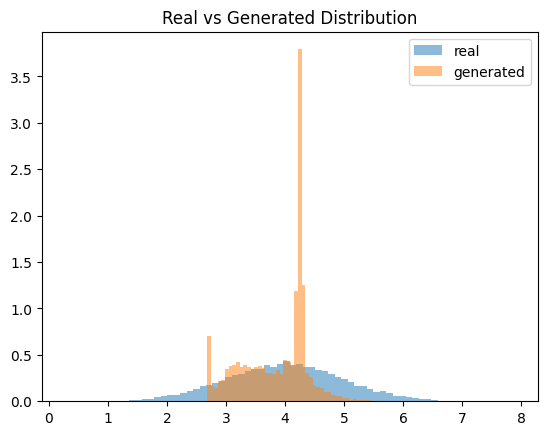

In [6]:
with torch.no_grad():
    real = sample_real(20000).cpu().numpy().ravel()
    fake = G(sample_noise(20000)).cpu().numpy().ravel()

print('Real mean/std:', real.mean(), real.std())
print('Fake mean/std:', fake.mean(), fake.std())

plt.hist(real, bins=70, density=True, alpha=0.5, label='real')
plt.hist(fake, bins=70, density=True, alpha=0.5, label='generated')
plt.legend()
plt.title('Real vs Generated Distribution')
plt.show()


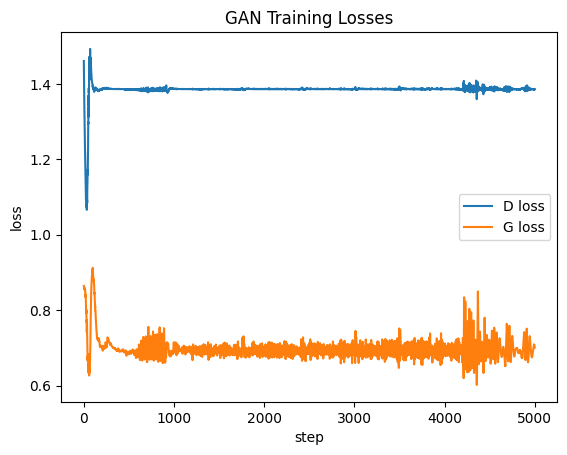

: 

In [ ]:
plt.plot(d_losses, label='D loss')
plt.plot(g_losses, label='G loss')
plt.xlabel('step')
plt.ylabel('loss')
plt.legend()
plt.title('GAN Training Losses')
plt.show()


## 핵심 해석

1. Discriminator: $D(x) \to 1$, $D(G(z)) \to 0$
2. Generator: $D(G(z)) \to 1$
3. 생성 분포가 실제 분포와 같아지면 D는 둘을 구분하기 어려워져 $D(x) \approx 0.5$가 됩니다.
